In [1]:
import os
# import ray

In [2]:
import sys

In [3]:
sys.version

'3.10.19 (main, Oct 10 2025, 08:52:10) [GCC 13.3.0]'

In [4]:
import ray

In [5]:
sys.path.append("..")
import warnings
warnings.filterwarnings("ignore")
from dotenv import load_dotenv
load_dotenv()
%load_ext autoreload
%autoreload 2

In [6]:
if ray.is_initialized():
    ray.shutdown()
ray.init()

2026-02-13 11:38:19,887	INFO worker.py:1633 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


Python version:,3.10.19
Ray version:,2.7.0
Dashboard:,http://127.0.0.1:8265


In [7]:
ray.cluster_resources()

{'node:__internal_head__': 1.0,
 'GPU': 1.0,
 'accelerator_type:G': 1.0,
 'CPU': 20.0,
 'memory': 4052024526.0,
 'object_store_memory': 2026012262.0,
 'node:192.168.137.72': 1.0}

In [8]:
num_workers_preprocess = 15
resources_per_worker_preprocess = {"CPU":1, "GPU":0}
num_workers_finetune = 1
resources_per_worker_finetune = {"CPU":1, "GPU":1}


# Data

## Data Ingestion

In [9]:
import pandas as pd

In [10]:
DATASET_LOC = "https://raw.githubusercontent.com/GokuMohandas/Made-With-ML/main/datasets/dataset.csv"
df = pd.read_csv(DATASET_LOC)
df.head()

,id,created_on,title,description,tag
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world...,Bringing theory to experiment is cool. We can ...,computer-vision
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for C...",The beauty of the work lies in the way it arch...,computer-vision
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, cla...",other
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search pape...,other
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: ...",other


## Data Splitting

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
df["tag"].value_counts()

tag
natural-language-processing    310
computer-vision                285
other                          106
mlops                           63
Name: count, dtype: int64

In [13]:
# Split dataset
test_size = 0.2
train_df, val_df = train_test_split(df, stratify=df["tag"], test_size=test_size, random_state=1234)

In [14]:
train_df["tag"].value_counts()

tag
natural-language-processing    248
computer-vision                228
other                           85
mlops                           50
Name: count, dtype: int64

In [15]:
val_df["tag"].value_counts()

tag
natural-language-processing    62
computer-vision                57
other                          21
mlops                          13
Name: count, dtype: int64

In [16]:
val_df["tag"].value_counts() * int((1-test_size) / test_size)

tag
natural-language-processing    248
computer-vision                228
other                           84
mlops                           52
Name: count, dtype: int64

## Exploratory Data Analysis

In [17]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from wordcloud import WordCloud, STOPWORDS
sns.set_theme()
warnings.filterwarnings("ignore")

In [18]:
# Most common tags
all_tags = Counter(df["tag"])
all_tags.most_common()

[('natural-language-processing', 310),
 ('computer-vision', 285),
 ('other', 106),
 ('mlops', 63)]

In [20]:
# Plot tag frequencies

tags, tag_counts = zip(*all_tags.most_common())
type(tags)

tuple

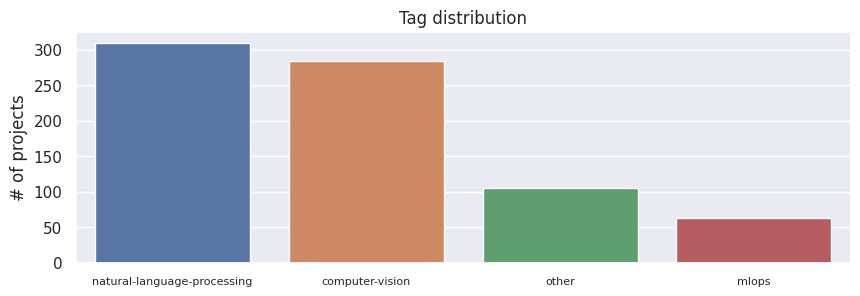

In [23]:
plt.figure(figsize=(10,3))
ax = sns.barplot(x=list(tags), y = list(tag_counts))
ax.set_xticklabels(tags, fontsize=8)
plt.title("Tag distribution")
plt.ylabel("# of projects")

plt.show()

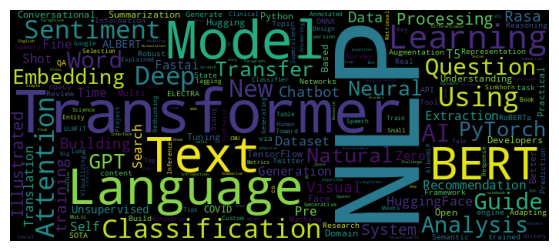

In [25]:
# Most frequent tokens for each tag
tag="natural-language-processing"
plt.figure(figsize=(10,3))
subset = df[df["tag"] == tag]
text = subset["title"].values
cloud = WordCloud(
    stopwords=STOPWORDS, background_color="black", collocations=False,
    width=700, height=300
).generate(" ".join(text))
plt.axis("off")
plt.imshow(cloud)

In [26]:
df.head(10)

,id,created_on,title,description,tag
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world...,Bringing theory to experiment is cool. We can ...,computer-vision
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for C...",The beauty of the work lies in the way it arch...,computer-vision
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, cla...",other
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search pape...,other
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: ...",other
5,27,2020-03-07 23:18:15,APPNP and PPNP,"A PyTorch implementation of ""Predict then Prop...",other
6,28,2020-03-07 23:23:46,Attributed Social Network Embedding,A sparsity aware and memory efficient implemen...,other
7,29,2020-03-07 23:45:38,Signed Graph Convolutional Network,"A PyTorch implementation of ""Signed Graph Conv...",other
8,45,2020-03-08 00:39:08,SimGNN,"A PyTorch implementation of ""SimGNN: A Neural ...",other
9,61,2020-03-16 17:35:22,Using JAX to Improve Separable Image Filters,Optimizing the filters to improve the filtered...,computer-vision
